In [61]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

In [62]:
from softisoics import isolated_halo

In [63]:
import importlib

importlib.reload(isolated_halo)

<module 'softisoics.isolated_halo' from '/Users/vinhtran/Data/Research/Mark/SoftIsoICs/SoftIsoICs/src/softisoics/isolated_halo.py'>

In [64]:
import matplotlib as mpl
from matplotlib import pyplot as plt

# define matplotlib style
plt.style.use("classic")
mpl.rc("xtick", labelsize=23)
mpl.rc("ytick", labelsize=23)
mpl.rc("xtick.major", size=15, width=2)
mpl.rc("xtick.minor", size=8, width=2, visible=True)
mpl.rc("ytick.major", size=15, width=2)
mpl.rc("ytick.minor", size=8, width=2, visible=True)
mpl.rc("lines", linewidth=3, markersize=20)
mpl.rc("axes", linewidth=2, labelsize=30, labelpad=2.5)
mpl.rc("legend", fontsize=25, loc="best", frameon=False, numpoints=1)

mpl.rc("font", family="STIXGeneral")
mpl.rc("mathtext", fontset="stix")

In [65]:
class NFWProfile(isolated_halo.BaseSingleComponentProfile):
    def __init__(self, c=10):
        self.c = c
        super().__init__()

    def _nfw_density(self, r):
        return 1 / r / (1 + r) ** 2

    def _decay_density(self, r):
        eps = 1 - (1 + 3 * self.c) / (1 + self.c)
        return (
            1
            / (self.c * (1 + self.c) ** 2)
            * (r / self.c) ** eps
            * np.exp(-(r / self.c - 1))
        )

    def _get_rho_bins(self, r_bins):
        return np.where(
            r_bins < self.c, self._nfw_density(r_bins), self._decay_density(r_bins)
        )

In [66]:
nfw_profile = NFWProfile()

r_bins = np.logspace(-3, 3, 1000)

rho_bins = nfw_profile._get_rho_bins(r_bins)
mass_bins = nfw_profile._get_mass_bins(r_bins, rho_bins)
phi_bins = nfw_profile._get_phi_bins(r_bins, mass_bins)
sigma_r_bins = nfw_profile._get_sigma_r_bins(r_bins, rho_bins, phi_bins)

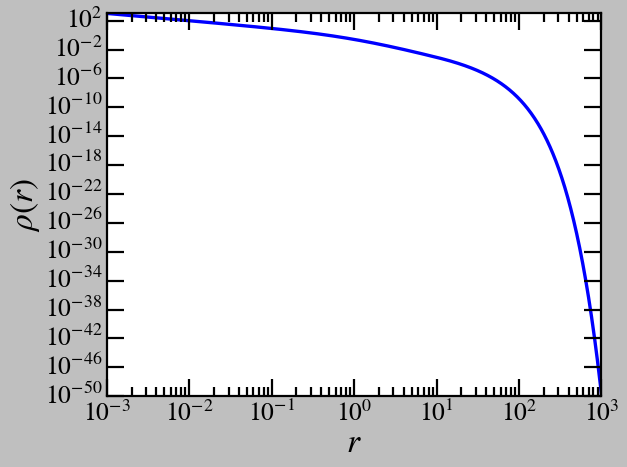

In [67]:
plt.plot(r_bins, rho_bins)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\rho (r)$")

plt.tight_layout()
plt.show()

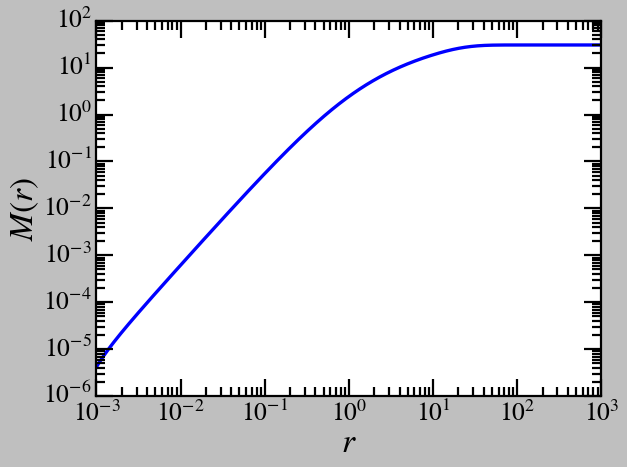

In [68]:
plt.plot(r_bins, mass_bins)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$M (r)$")

plt.tight_layout()
plt.show()

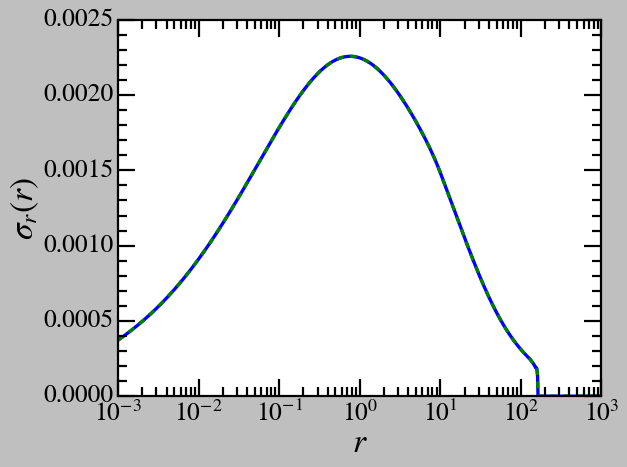

In [69]:
_delta_rho_sigma_r_sqr_integrand = (
    rho_bins * np.gradient(phi_bins, np.log(r_bins)) / r_bins
)
_delta_rho_sigma_r_sqr_bins = cumulative_trapezoid(
    _delta_rho_sigma_r_sqr_integrand, r_bins, initial=0
)
sigma_r_bins_prime = np.sqrt(
    (_delta_rho_sigma_r_sqr_bins[-1] - _delta_rho_sigma_r_sqr_bins) / rho_bins
)

plt.plot(r_bins, sigma_r_bins)
plt.plot(r_bins, sigma_r_bins_prime, ls="--")

plt.xscale("log")
# plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r (r)$")

plt.tight_layout()
plt.show()